# Chapter 3: Likelihood Functions and Prior Selection

The likelihood is the bridge between data and parameters.
In this notebook we build likelihoods from first principles for the noise models
that appear most often in astrophysics, then explore principled prior selection.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
np.random.seed(42)
print("Ready.")


Ready.


## 3.1 Constructing Likelihoods from Physics

The likelihood P(D|θ) = **noise model evaluated at the residuals**.

**Step 1:** Write down the physical model: m(t; θ)  
**Step 2:** Identify the noise distribution: d_i = m(t_i; θ) + ε_i  
**Step 3:** The likelihood is ∏ᵢ P(ε_i) = ∏ᵢ P(dᵢ - m(tᵢ; θ))

### Gaussian Likelihood (high-count spectroscopy, photometry)

$$\ln \mathcal{L}(\theta) = -\frac{1}{2} \sum_{i=1}^N \left[\frac{(d_i - m_i(\theta))^2}{\sigma_i^2} + \ln(2\pi\sigma_i^2)\right] = -\frac{1}{2}\chi^2$$

**MLE with Gaussian noise = minimising χ² = least squares.** Least squares is a special case of Bayesian inference with Gaussian noise and flat priors!


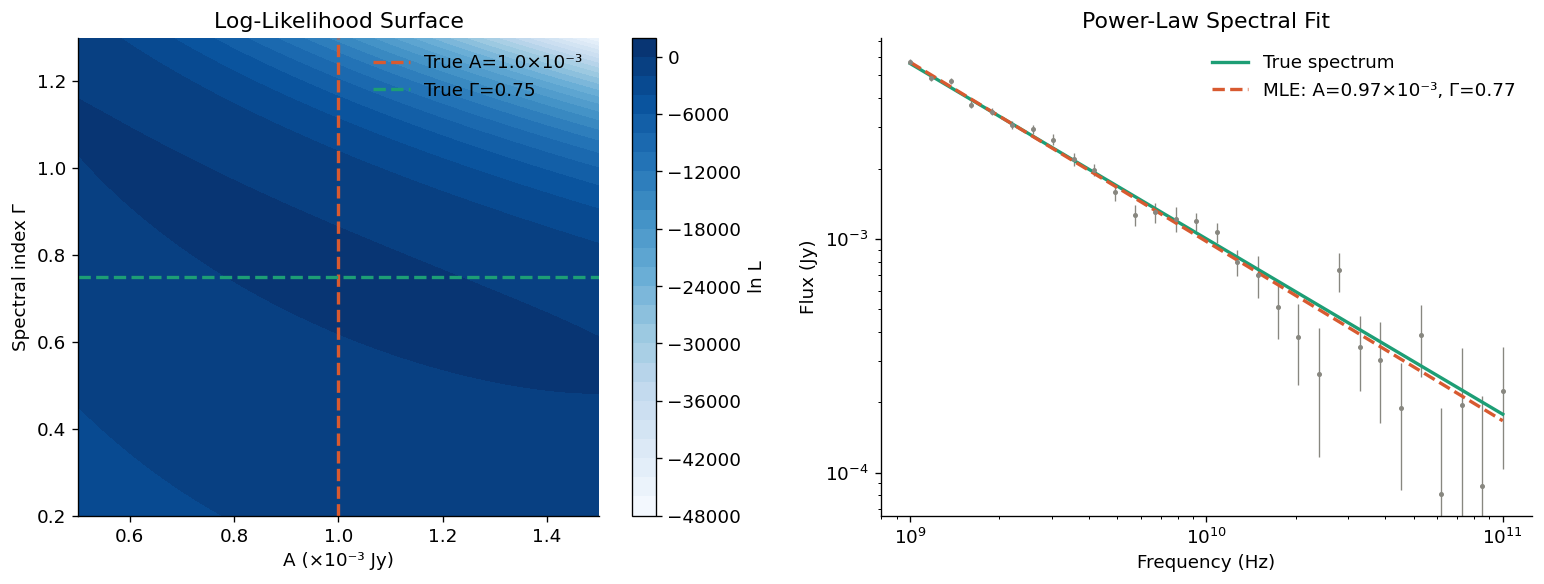

In [2]:
# Demonstrate: Gaussian log-likelihood = -½ χ²
# Fit a spectral model: power law F(ν) = A * (ν/ν₀)^(-Γ)

np.random.seed(0)
nu     = np.logspace(9, 11, 30)       # frequency (Hz)
nu0    = 1e10                           # reference frequency
A_true, Gamma_true = 1e-3, 0.75

# Simulate observations with heteroscedastic noise
sigma_i = 1e-4 * (1 + 0.5*np.random.rand(len(nu)))  # varying errors
F_true  = A_true * (nu/nu0)**(-Gamma_true)
F_obs   = F_true + sigma_i * np.random.randn(len(nu))

def log_likelihood_gaussian(A, Gamma, nu, F_obs, sigma):
    F_model = A * (nu/nu0)**(-Gamma)
    return -0.5 * np.sum(((F_obs - F_model)/sigma)**2 + np.log(2*np.pi*sigma**2))

# 2D likelihood surface
A_grid     = np.linspace(0.5e-3, 1.5e-3, 100)
Gamma_grid = np.linspace(0.2, 1.3, 100)
AA, GG     = np.meshgrid(A_grid, Gamma_grid)
LL = np.array([[log_likelihood_gaussian(a, g, nu, F_obs, sigma_i)
                for a in A_grid] for g in Gamma_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Likelihood surface
cf = axes[0].contourf(A_grid*1e3, Gamma_grid, LL, levels=30, cmap="Blues")
axes[0].axvline(A_true*1e3, color="#D85A30", lw=2, ls="--", label=f"True A={A_true*1e3:.1f}×10⁻³")
axes[0].axhline(Gamma_true, color="#1D9E75", lw=2, ls="--", label=f"True Γ={Gamma_true}")
axes[0].set_xlabel("A (×10⁻³ Jy)")
axes[0].set_ylabel("Spectral index Γ")
axes[0].set_title("Log-Likelihood Surface")
axes[0].legend(frameon=False)
plt.colorbar(cf, ax=axes[0], label="ln L")

# Best-fit spectrum
idx = np.unravel_index(LL.argmax(), LL.shape)
A_mle, Gamma_mle = A_grid[idx[1]], Gamma_grid[idx[0]]
nu_plot = np.logspace(9, 11, 200)
axes[1].errorbar(nu, F_obs, yerr=sigma_i, fmt='.', color="#888780", ms=4, elinewidth=0.8)
axes[1].plot(nu_plot, A_true*(nu_plot/nu0)**(-Gamma_true), "#1D9E75", lw=2, label="True spectrum")
axes[1].plot(nu_plot, A_mle*(nu_plot/nu0)**(-Gamma_mle),  "#D85A30", lw=2, ls="--",
             label=f"MLE: A={A_mle*1e3:.2f}×10⁻³, Γ={Gamma_mle:.2f}")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Flux (Jy)")
axes[1].set_title("Power-Law Spectral Fit")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 3.2 Poisson Likelihood — Low-Count X-ray Spectra

When photon counts are low (< ~20 per bin), the Poisson likelihood must be used:

$$\ln \mathcal{L}(\theta) = \sum_{i=1}^N \left[n_i \ln \mu_i(\theta) - \mu_i(\theta)\right]$$

(The -ln(nᵢ!) term is a constant and can be dropped for optimisation.)

This is the **C-statistic** (Cash 1979) used throughout X-ray astronomy.


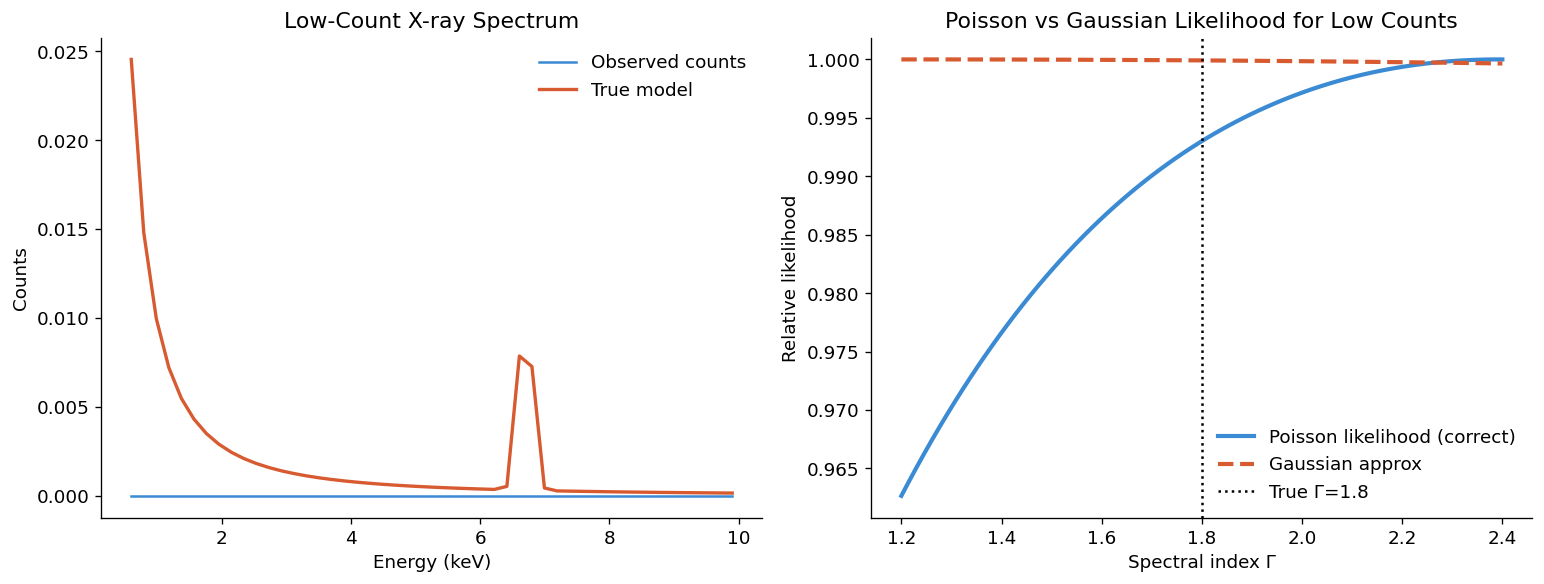

Mean counts per bin: 0.0
→ At this count level, Poisson and Gaussian likelihoods give similar answers.
  Difference becomes critical when mean counts < 5.


In [3]:
# Poisson vs Gaussian likelihood: when does it matter?
# Simulate an X-ray spectrum at low counts

np.random.seed(99)
E_bins  = np.linspace(0.5, 10, 50)       # keV
E_mid   = 0.5*(E_bins[:-1] + E_bins[1:]) # bin centres
dE      = np.diff(E_bins)

# True model: power law + emission line
Gamma_true = 1.8
norm_true  = 0.05
line_A     = 0.015
line_E     = 6.7   # Fe K-alpha
line_sig   = 0.1

mu_true = (norm_true * E_mid**(-Gamma_true) +
           line_A * stats.norm.pdf(E_mid, line_E, line_sig)) * dE

counts = np.random.poisson(mu_true)       # observed counts

def log_like_poisson(Gamma, norm, E_mid, dE, n_obs, line_A=0.015):
    mu = (norm * E_mid**(-Gamma) +
          line_A * stats.norm.pdf(E_mid, line_E, line_sig)) * dE
    mu = np.clip(mu, 1e-10, None)
    return np.sum(n_obs * np.log(mu) - mu)

def log_like_gaussian(Gamma, norm, E_mid, dE, n_obs, line_A=0.015):
    mu    = (norm * E_mid**(-Gamma) +
             line_A * stats.norm.pdf(E_mid, line_E, line_sig)) * dE
    sigma = np.sqrt(np.clip(mu, 1, None))   # Poisson approximation
    return -0.5 * np.sum(((n_obs - mu)/sigma)**2)

G_grid = np.linspace(1.2, 2.4, 80)
pois_ll = [log_like_poisson(g, norm_true, E_mid, dE, counts) for g in G_grid]
gaus_ll = [log_like_gaussian(g, norm_true, E_mid, dE, counts) for g in G_grid]

# Normalise to compare shapes
pois_ll = np.array(pois_ll); pois_ll -= pois_ll.max()
gaus_ll = np.array(gaus_ll); gaus_ll -= gaus_ll.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].step(E_mid, counts, where="mid", color="#3B8BD4", lw=1.5, label="Observed counts")
axes[0].plot(E_mid, mu_true, "#D85A30", lw=2, label="True model")
axes[0].set_xlabel("Energy (keV)"); axes[0].set_ylabel("Counts")
axes[0].set_title("Low-Count X-ray Spectrum")
axes[0].legend(frameon=False)

axes[1].plot(G_grid, np.exp(pois_ll), "#3B8BD4", lw=2.5, label="Poisson likelihood (correct)")
axes[1].plot(G_grid, np.exp(gaus_ll), "#D85A30", lw=2.5, ls="--", label="Gaussian approx")
axes[1].axvline(Gamma_true, color="black", lw=1.5, ls=":", label=f"True Γ={Gamma_true}")
axes[1].set_xlabel("Spectral index Γ"); axes[1].set_ylabel("Relative likelihood")
axes[1].set_title("Poisson vs Gaussian Likelihood for Low Counts")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()
print(f"Mean counts per bin: {counts.mean():.1f}")
print("→ At this count level, Poisson and Gaussian likelihoods give similar answers.")
print("  Difference becomes critical when mean counts < 5.")


## 3.3 Prior Selection

The prior P(θ) encodes knowledge before seeing the data.

### Types of priors:

| Type | Form | Use case |
|------|------|----------|
| Uniform | P(θ) ∝ 1 on [a,b] | Bounded parameters, vague knowledge |
| Log-uniform | P(θ) ∝ 1/θ | Scale parameters spanning orders of magnitude |
| Jeffreys | P(θ) ∝ √det F(θ) | Invariant under reparametrisation |
| Gaussian | P(θ) = N(μ₀, σ₀²) | Previous measurements as prior |
| Half-Gaussian | P(θ) for θ > 0 | Positive scale parameters |


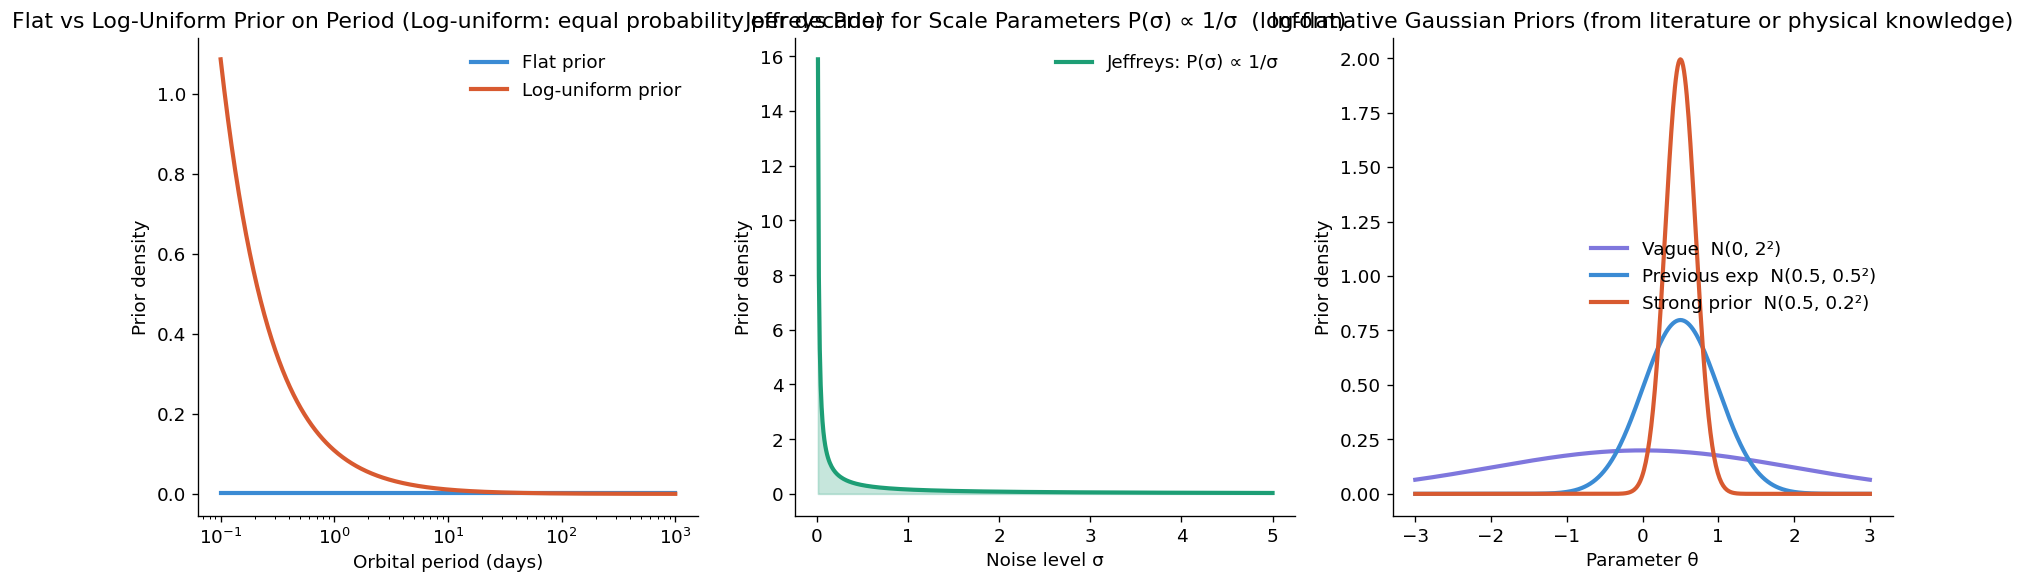

In [7]:
# Compare priors: what do they look like and what do they imply?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Flat vs log-uniform for a period parameter
P_grid = np.logspace(-1, 3, 500)   # periods from 0.1 to 1000 days

flat_prior    = np.ones_like(P_grid) / (P_grid[-1] - P_grid[0])
logunif_prior = 1.0 / (P_grid * np.log(P_grid[-1]/P_grid[0]))

axes[0].plot(P_grid, flat_prior,    "#3B8BD4", lw=2.5, label="Flat prior")
axes[0].plot(P_grid, logunif_prior, "#D85A30", lw=2.5, label="Log-uniform prior")
axes[0].set_xscale("log")
axes[0].set_xlabel("Orbital period (days)")
axes[0].set_ylabel("Prior density")
axes[0].set_title("Flat vs Log-Uniform Prior on Period (Log-uniform: equal probability per decade)")
axes[0].legend(frameon=False)

# 2. Jeffreys prior for Gaussian sigma
sigma_grid = np.linspace(0.01, 5, 500)
jeffreys_sigma = 1.0 / sigma_grid                           # P(σ) ∝ 1/σ
jeffreys_sigma /= np.trapezoid(jeffreys_sigma, sigma_grid)

axes[1].plot(sigma_grid, jeffreys_sigma, "#1D9E75", lw=2.5, label="Jeffreys: P(σ) ∝ 1/σ")
axes[1].fill_between(sigma_grid, jeffreys_sigma, alpha=0.25, color="#1D9E75")
axes[1].set_xlabel("Noise level σ")
axes[1].set_ylabel("Prior density")
axes[1].set_title("Jeffreys Prior for Scale Parameters P(σ) ∝ 1/σ  (log-flat)")
axes[1].legend(frameon=False)

# 3. Informative Gaussian prior from a previous experiment
theta_grid = np.linspace(-3, 3, 500)
priors_info = [
    (0.0, 2.0, "#7F77DD", "Vague  N(0, 2²)"),
    (0.5, 0.5, "#3B8BD4", "Previous exp  N(0.5, 0.5²)"),
    (0.5, 0.2, "#D85A30", "Strong prior  N(0.5, 0.2²)"),
]
for mu, sig, col, label in priors_info:
    axes[2].plot(theta_grid, stats.norm.pdf(theta_grid, mu, sig),
                 color=col, lw=2.5, label=label)
axes[2].set_xlabel("Parameter θ")
axes[2].set_ylabel("Prior density")
axes[2].set_title("Informative Gaussian Priors (from literature or physical knowledge)")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()


## 3.4 Prior Sensitivity Analysis

A robust analysis should not depend strongly on the prior choice.
**If data dominate**: posteriors converge regardless of prior → conclusion is solid.  
**If priors dominate**: collect more data, or justify the prior with physical arguments.


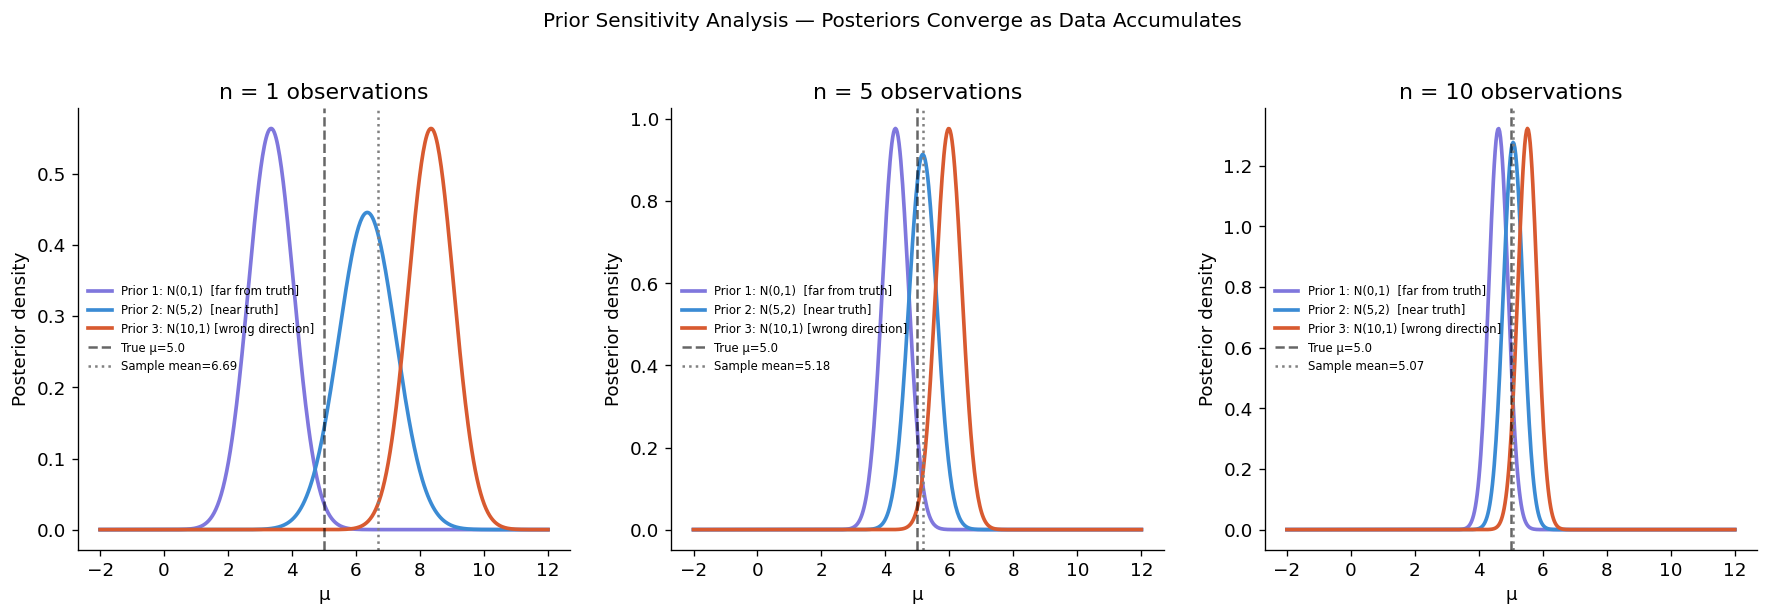

With n=1: priors dominate (posteriors differ significantly)
With n=10: data dominate (posteriors nearly identical regardless of prior)


In [8]:
# Prior sensitivity: how much does the prior choice matter?
np.random.seed(7)

# True parameter: mu = 5.0
mu_true = 5.0
sigma   = 1.0
n_obs   = 10
data    = np.random.normal(mu_true, sigma, n_obs)

# Three different priors
mu_grid = np.linspace(-2, 12, 500)

priors_list = [
    (0.0, 1.0, "#7F77DD", "Prior 1: N(0,1)  [far from truth]"),
    (5.0, 2.0, "#3B8BD4", "Prior 2: N(5,2)  [near truth]"),
    (10., 1.0, "#D85A30", "Prior 3: N(10,1) [wrong direction]"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for n_show in [1, 5, 10]:
    ax = axes[[1,5,10].index(n_show)]
    data_subset = data[:n_show]

    for prior_mu, prior_sig, col, label in priors_list:
        # Analytic Gaussian posterior
        prior_var  = prior_sig**2
        like_var   = (sigma/np.sqrt(n_show))**2
        post_var   = 1.0/(1.0/prior_var + 1.0/like_var)
        post_mu    = post_var*(prior_mu/prior_var + data_subset.mean()/like_var)

        ax.plot(mu_grid, stats.norm.pdf(mu_grid, post_mu, np.sqrt(post_var)),
                color=col, lw=2.2, label=label)

    ax.axvline(mu_true, color="black", lw=1.5, ls="--", alpha=0.6,
               label=f"True μ={mu_true}")
    ax.axvline(data_subset.mean(), color="gray", lw=1.5, ls=":",
               label=f"Sample mean={data_subset.mean():.2f}")
    ax.set_xlabel("μ"); ax.set_ylabel("Posterior density")
    ax.set_title(f"n = {n_show} observations")
    ax.legend(fontsize=7, frameon=False)

plt.suptitle("Prior Sensitivity Analysis — Posteriors Converge as Data Accumulates",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("With n=1: priors dominate (posteriors differ significantly)")
print("With n=10: data dominate (posteriors nearly identical regardless of prior)")


## 3.5 Nuisance Parameters and Marginalisation

Real data analyses have parameters we don't care about (nuisance parameters).
Bayesian marginalisation handles them correctly by integrating them out.

**Example:** Fitting a spectral line amplitude A with an uncertain background level B.


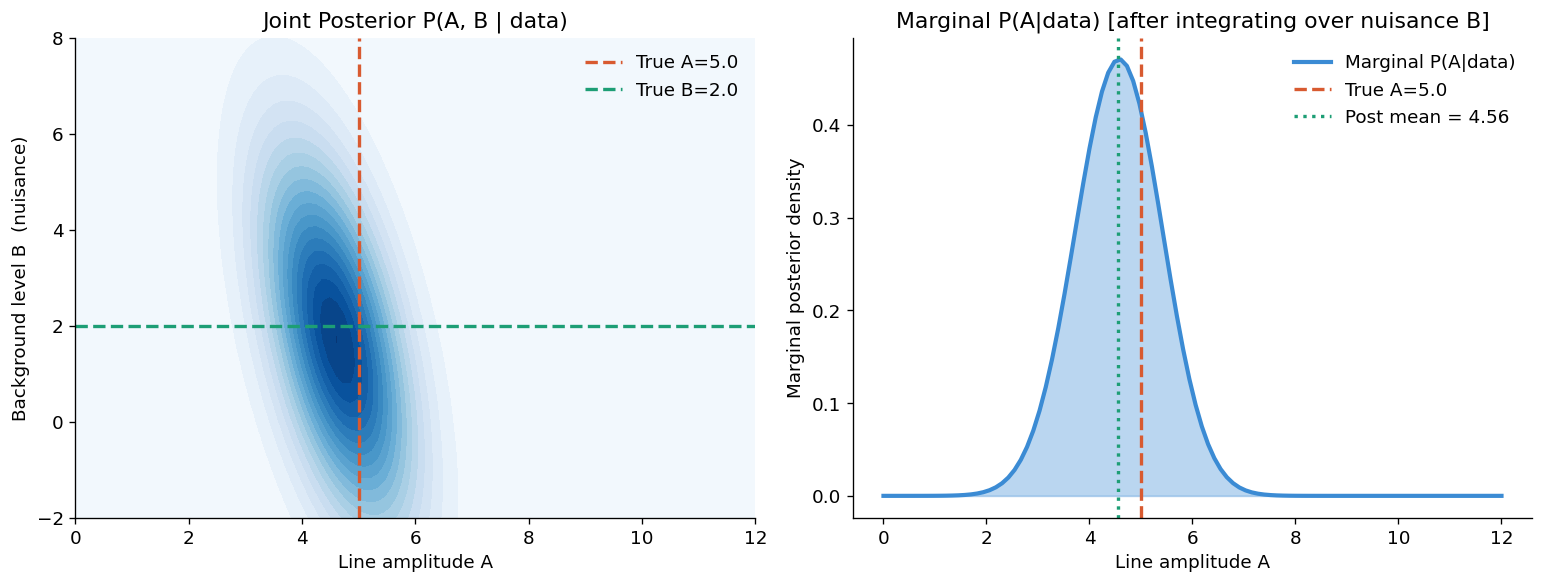

Posterior mean of A = 4.56  (true A = 5.0)


In [11]:
# Joint posterior + marginalisation over nuisance parameter
# Model: spectrum = A * line_profile + B * background
# We want the posterior on A; B is a nuisance

np.random.seed(3)
A_true, B_true = 5.0, 2.0
sigma_noise = 1.0
n_bins = 20
x = np.linspace(-3, 3, n_bins)
line_profile = stats.norm.pdf(x, 0, 0.5)
background   = np.ones(n_bins) * 0.1

data_obs = (A_true * line_profile + B_true * background +
            sigma_noise * np.random.randn(n_bins))

# Compute 2D posterior P(A, B | data) on a grid
A_grid = np.linspace(0, 12, 100)
B_grid = np.linspace(-2, 8, 100)

log_post = np.zeros((len(B_grid), len(A_grid)))
for j, A in enumerate(A_grid):
    for i, B in enumerate(B_grid):
        residuals = data_obs - A*line_profile - B*background
        log_post[i, j] = -0.5 * np.sum(residuals**2 / sigma_noise**2)

post_2d = np.exp(log_post - log_post.max())
post_2d /= post_2d.sum()

# Marginal on A (integrate over B)
dB = B_grid[1] - B_grid[0]
marginal_A = post_2d.sum(axis=0) * dB
marginal_A /= np.trapezoid(marginal_A, A_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 2D joint posterior
axes[0].contourf(A_grid, B_grid, post_2d, levels=20, cmap="Blues")
axes[0].axvline(A_true, color="#D85A30", lw=2, ls="--", label=f"True A={A_true}")
axes[0].axhline(B_true, color="#1D9E75", lw=2, ls="--", label=f"True B={B_true}")
axes[0].set_xlabel("Line amplitude A")
axes[0].set_ylabel("Background level B  (nuisance)")
axes[0].set_title("Joint Posterior P(A, B | data)") 
axes[0].legend(frameon=False)

# Marginal on A
axes[1].fill_between(A_grid, marginal_A, alpha=0.35, color="#3B8BD4")
axes[1].plot(A_grid, marginal_A, "#3B8BD4", lw=2.5, label="Marginal P(A|data)")
axes[1].axvline(A_true, color="#D85A30", lw=2, ls="--", label=f"True A={A_true}")
post_mean = np.trapezoid(A_grid * marginal_A, A_grid)
axes[1].axvline(post_mean, color="#1D9E75", lw=2, ls=":",
                label=f"Post mean = {post_mean:.2f}")
axes[1].set_xlabel("Line amplitude A")
axes[1].set_ylabel("Marginal posterior density")
axes[1].set_title("Marginal P(A|data) [after integrating over nuisance B]")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()
print(f"Posterior mean of A = {post_mean:.2f}  (true A = {A_true})")


In [12]:
print("Chapter 3 complete! Key takeaways:")
print("  - Gaussian likelihood <=> minimising chi-squared (least squares is a special case)")
print("  - Poisson likelihood required for low counts (<20 per bin)")
print("  - Log-uniform priors appropriate for scale parameters (mass, luminosity, period)")
print("  - Prior sensitivity: run your analysis with 2-3 different priors")
print("  - Marginalisation correctly propagates nuisance parameter uncertainty")


Chapter 3 complete! Key takeaways:
  - Gaussian likelihood <=> minimising chi-squared (least squares is a special case)
  - Poisson likelihood required for low counts (<20 per bin)
  - Log-uniform priors appropriate for scale parameters (mass, luminosity, period)
  - Prior sensitivity: run your analysis with 2-3 different priors
  - Marginalisation correctly propagates nuisance parameter uncertainty
